<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/WeeklyModules/Week12/PARTICIPATION_ACTIVITY_Week_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Connect to my GitHub repository using the file distributed in class
%run '/content/drive/MyDrive/Google_connection.py'

Changed directory to: /content/MSSP6070


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# seaborn is a package for the visualization of statistical data
import seaborn as sns
from scipy.stats import ttest_ind
from pathlib import Path

sns.set(style='ticks')

# Load the dataset
DATA_PATH = Path("/content/drive/MyDrive/MSSP607/Modules/Week12/Student Performance Data.csv")
df = pd.read_csv(DATA_PATH, encoding="latin-1", low_memory=False)

print("Libraries imported and data loaded successfully. Displaying first 5 rows of df:")
display(df.head())

Libraries imported and data loaded successfully. Displaying first 5 rows of df:


,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high


## Data Preparation and T-test for Male Students

This section prepares the data for the t-test by filtering male students and separating them into groups based on whether they completed the 'test preparation course'. It then performs independent sample t-tests for math, reading, and writing scores, comparing the two groups.

In [28]:
# 1. Filter for male students
male_students_df = df[df['gender'] == 'male']

# 2. Separate male students into two groups based on 'test preparation course' and create copies
male_completed_prep = male_students_df[male_students_df['test preparation course'] == 'completed'].copy()
male_not_completed_prep = male_students_df[male_students_df['test preparation course'] == 'none'].copy()

# 3. Ensure score columns are numeric for both groups
score_columns = ['math score', 'reading score', 'writing score']
for col in score_columns:
    male_completed_prep[col] = pd.to_numeric(male_completed_prep[col], errors='coerce')
    male_not_completed_prep[col] = pd.to_numeric(male_not_completed_prep[col], errors='coerce')

# 4. Combine for visualization and add 'Test Prep Status'
male_completed_prep['Test Prep Status'] = 'completed'
male_not_completed_prep['Test Prep Status'] = 'none'
male_scores_combined = pd.concat([male_completed_prep, male_not_completed_prep])

print("Data preparation for T-test complete. Proceeding with T-tests:")
alpha = 0.05

for score_type in score_columns:
    scores_completed = male_completed_prep[score_type].dropna()
    scores_not_completed = male_not_completed_prep[score_type].dropna()

    t_statistic, p_value = ttest_ind(scores_completed, scores_not_completed, equal_var=False)

    print(f"\n--- {score_type.replace(' score', '').capitalize()} Scores ---")
    print(f"T-statistic: {t_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < alpha:
        print(f"The difference in {score_type} between the two groups is statistically significant (p < {alpha}).")
    else:
        print(f"The difference in {score_type} between the two groups is NOT statistically significant (p >= {alpha}).")

Data preparation for T-test complete. Proceeding with T-tests:

--- Math Scores ---
T-statistic: 4.2080
P-value: 0.0000
The difference in math score between the two groups is statistically significant (p < 0.05).

--- Reading Scores ---
T-statistic: 5.7663
P-value: 0.0000
The difference in reading score between the two groups is statistically significant (p < 0.05).

--- Writing Scores ---
T-statistic: 8.1382
P-value: 0.0000
The difference in writing score between the two groups is statistically significant (p < 0.05).


##Interpretation:
A p-value of 0.0000, being much less than the conventional significance level (alpha = 0.05), indicates strong evidence against the null hypothesis. The null hypothesis in this case would be that there is no difference in scores between male students who completed the test preparation course and those who did not.

## Explore Other Differences of Interest

This section explores how other categorical variables ('parental level of education', 'lunch', 'race/ethnicity') relate to student scores by displaying descriptive statistics and mean scores grouped by these categories.

In [29]:
print("Descriptive statistics for all score columns:")
display(df[score_columns].describe())

categorical_vars_to_explore = ['parental level of education', 'lunch', 'race/ethnicity']

for category in categorical_vars_to_explore:
    print(f"\nMean scores grouped by '{category}':")
    display(df.groupby(category)[score_columns].mean())

Descriptive statistics for all score columns:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



Mean scores grouped by 'parental level of education':


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268



Mean scores grouped by 'lunch':


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



Mean scores grouped by 'race/ethnicity':


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


## Visualizing Key Findings

This section generates box plots to visualize the t-test results for male students (scores by test prep status) and grouped bar plots to show mean scores across different parental education levels, lunch types, and race/ethnicity groups.

Generating box plots for male students' scores by test preparation status...


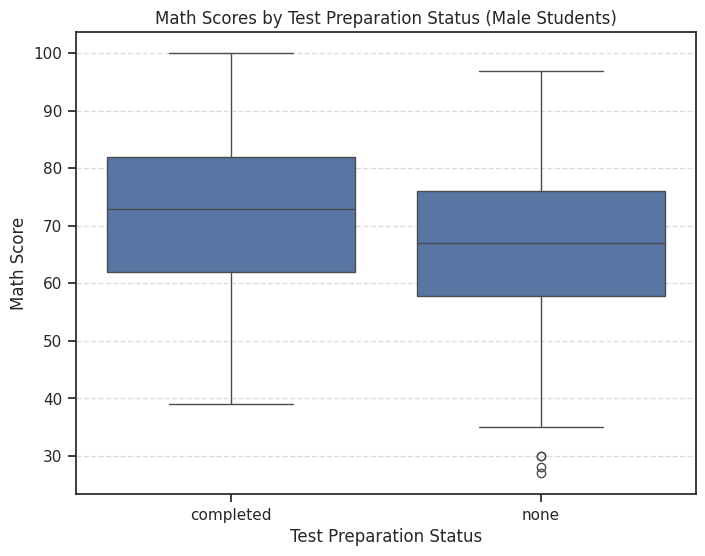

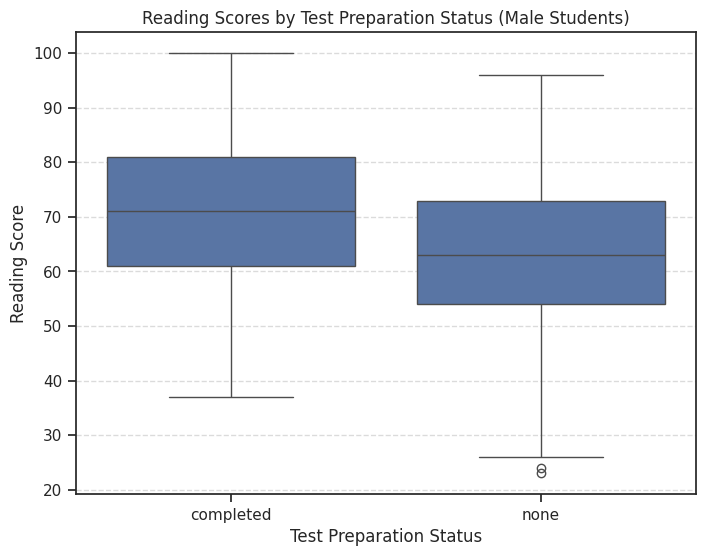

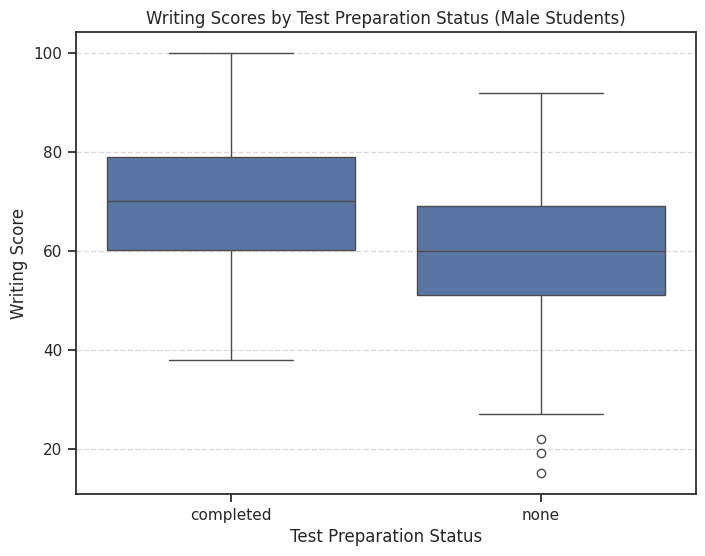


Generating grouped bar plots for other categorical variables...


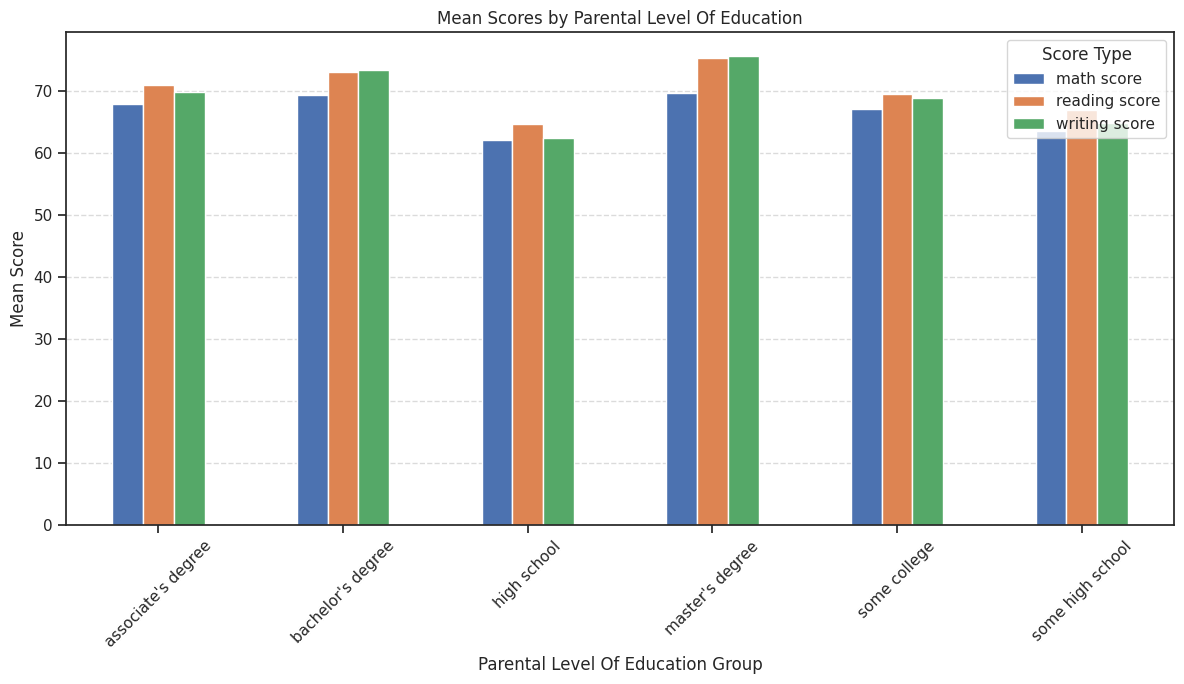

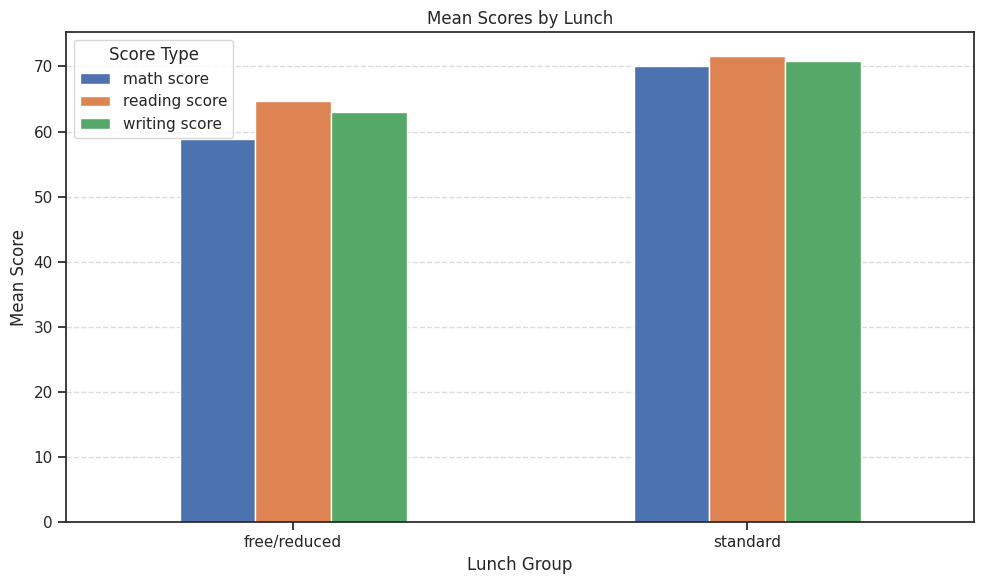

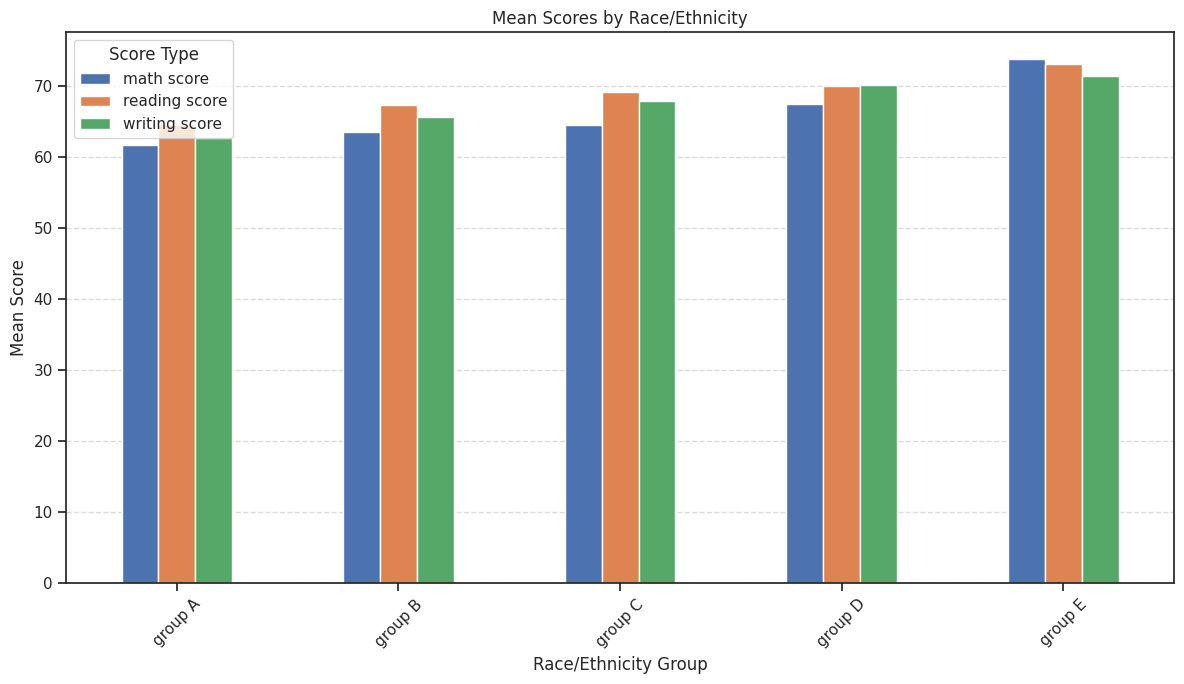

In [30]:
# Box Plots for Test Prep Status (Male Students)
print("Generating box plots for male students' scores by test preparation status...")
for score_type in score_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Test Prep Status', y=score_type, data=male_scores_combined)
    plt.title(f'{score_type.replace(" score", "").capitalize()} Scores by Test Preparation Status (Male Students)')
    plt.xlabel('Test Preparation Status')
    plt.ylabel(score_type.replace(" score", "").capitalize() + ' Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Grouped Bar Plots for Other Categorical Variables
print("\nGenerating grouped bar plots for other categorical variables...")
categorical_vars_to_explore = ['parental level of education', 'lunch', 'race/ethnicity']

for category in categorical_vars_to_explore:
    grouped_scores = df.groupby(category)[score_columns].mean()
    plt.figure(figsize=(12, 7) if category != 'lunch' else (10, 6)) # Adjust size for 'lunch' for better readability
    grouped_scores.plot(kind='bar', ax=plt.gca(), rot=45 if category != 'lunch' else 0)
    plt.title(f'Mean Scores by {category.replace("_", " ").title()}')
    plt.xlabel(category.replace("_", " ").title() + ' Group')
    plt.ylabel('Mean Score')
    plt.legend(title='Score Type')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#Interpretation:
**Parental Level of Education**: We generally observe a positive correlation between parental education level and student scores. Students whose parents have higher academic degrees (like Master's or Bachelor's) tend to achieve higher average scores in all subjects compared to those whose parents have a high school education or less.

**Lunch Type**: There's a clear difference in performance based on lunch type. Students receiving 'standard' lunch consistently score significantly higher in math, reading, and writing than those receiving 'free/reduced' lunch.

**Race/Ethnicity**: The mean scores vary across different racial/ethnic groups. 'Group E' generally demonstrates the highest average scores across all subjects, while 'Group A' and 'Group B' tend to have slightly lower average scores compared to other groups.